This notebook processes the outputs of `brute_force_mixing.py` for full-augmentation experiments only.

It analyzes the `expected_coef_all_groups_full_aug` results and excludes partial-augmentation comparisons.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (needed for 3D)
import pickle

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from regressor import ExpPerceptronRegressor, PolynomialRegressor

In [2]:
SMALL_SIZE = 18
MEDIUM_SIZE = 24
BIGGER_SIZE = 24
plt.rc('font', size=SMALL_SIZE, family = "Nimbus Roman")          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
# plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [83]:
# Load mixing ratios and metrics (full augmentation only)
# exp_name = "expected_coef_all_groups_full_aug"
exp_name = "movielens-min-users-700"
all_labels = ["1", "18", "25", "35", "45", "50", "56"]
filename = f"../results/mixing_results_by_group_{exp_name}.pickle"
with open(filename, "rb") as pickleFile:
    mixing_results_by_group = pickle.load(pickleFile)

for label in mixing_results_by_group:
    assert len(mixing_results_by_group[label]["validation ps"]) == len(mixing_results_by_group[label]["validation metrics"])
    print(f"{label}: {len(mixing_results_by_group[label]['validation ps'])} trials")
    
    ps = mixing_results_by_group[label]["validation ps"]
    group_labels = set(ps[0].keys())
    assert np.all([group_labels == set(p.keys()) for p in ps])
    
    metric_dicts = mixing_results_by_group[label]["validation metrics"]
    metric_names = set(metric_dicts[0].keys())
    assert np.all([metric_names == set(metric_dict.keys()) for metric_dict in metric_dicts])


1: 500 trials
18: 500 trials
25: 500 trials
35: 500 trials
45: 500 trials
50: 500 trials
56: 500 trials


## Analyzing Best Mixing Ratios

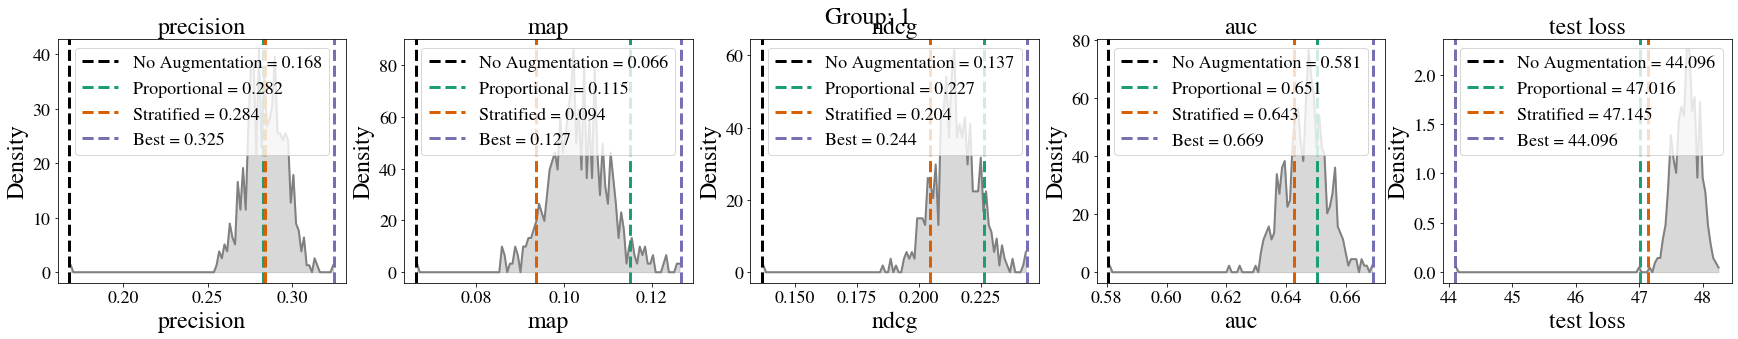

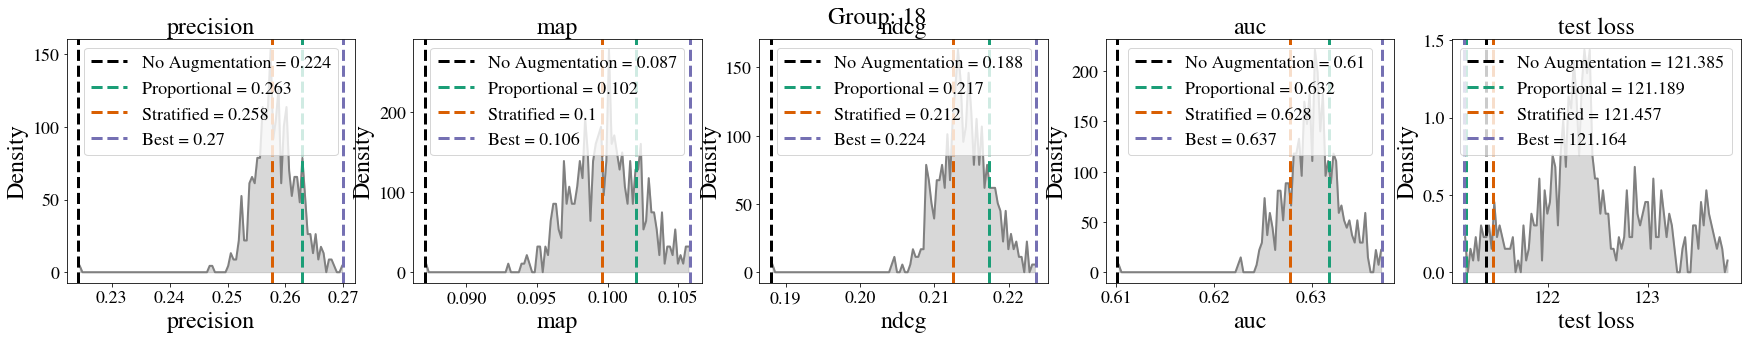

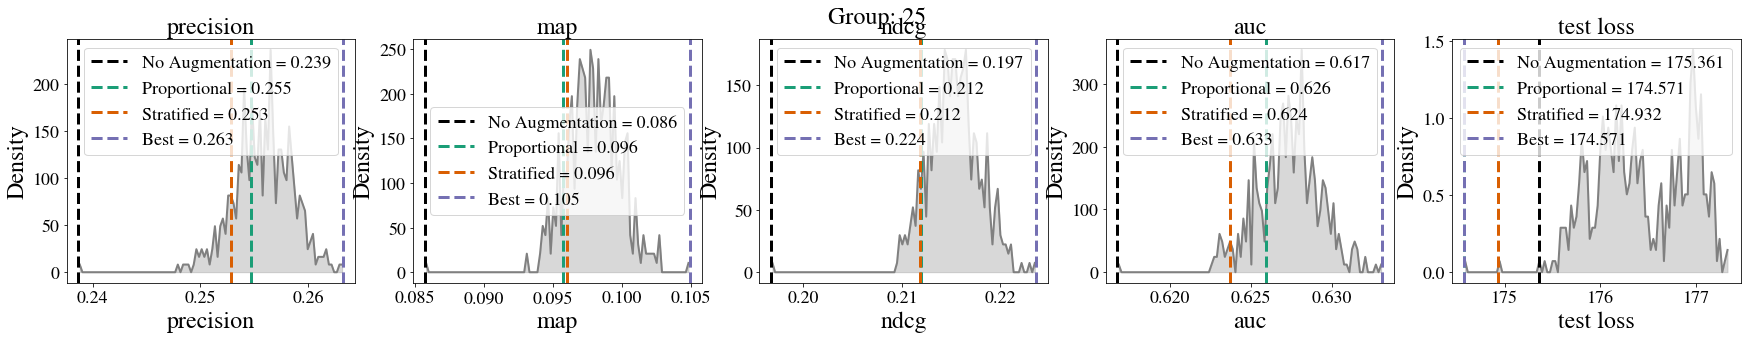

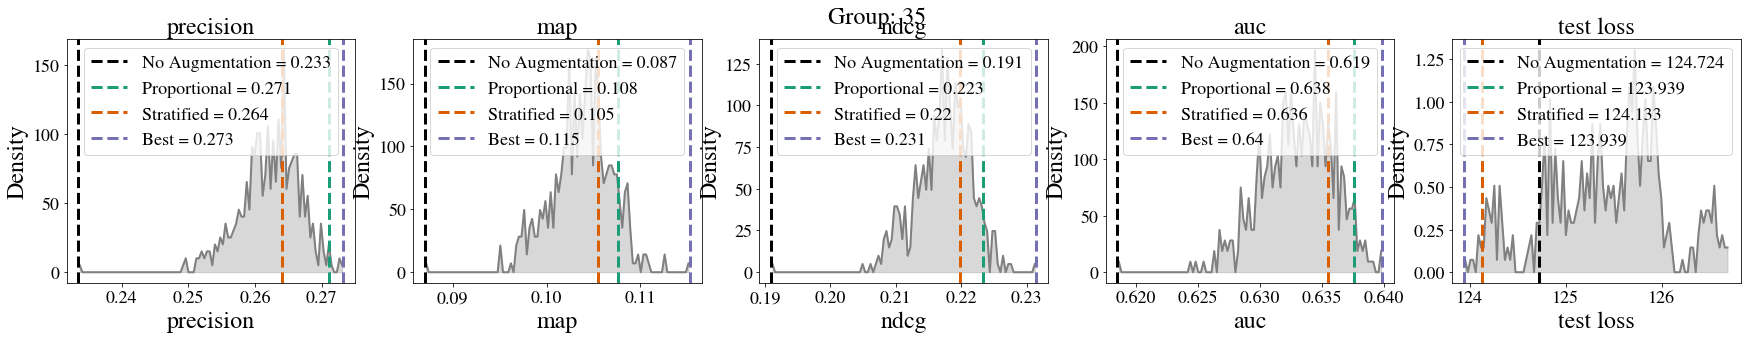

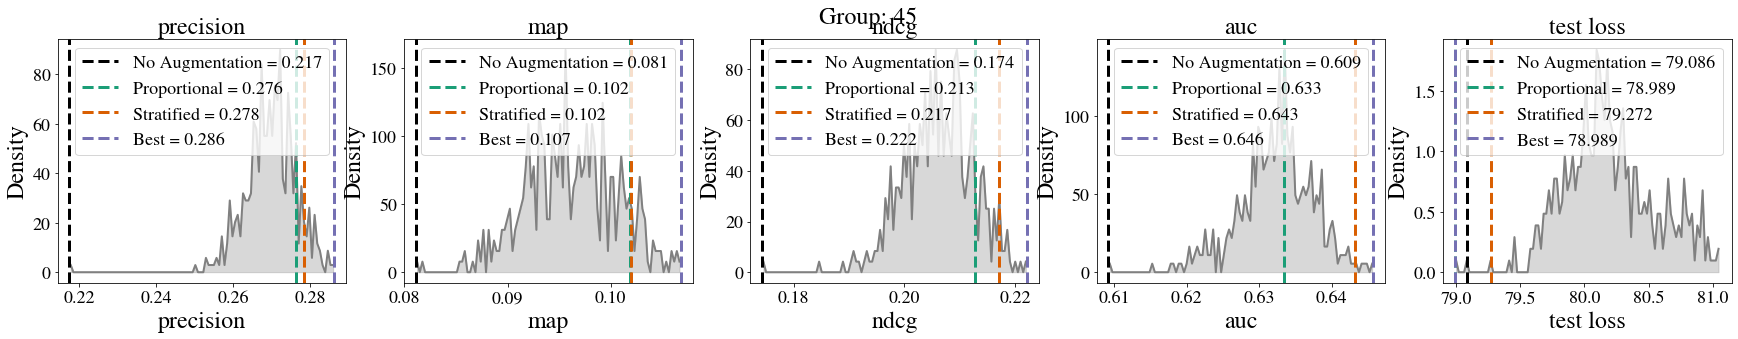

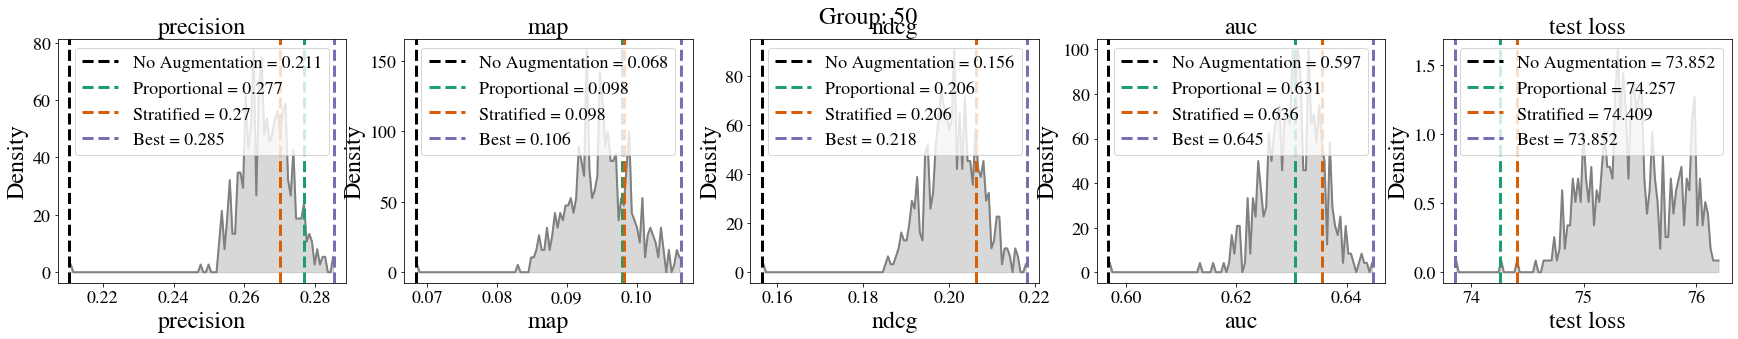

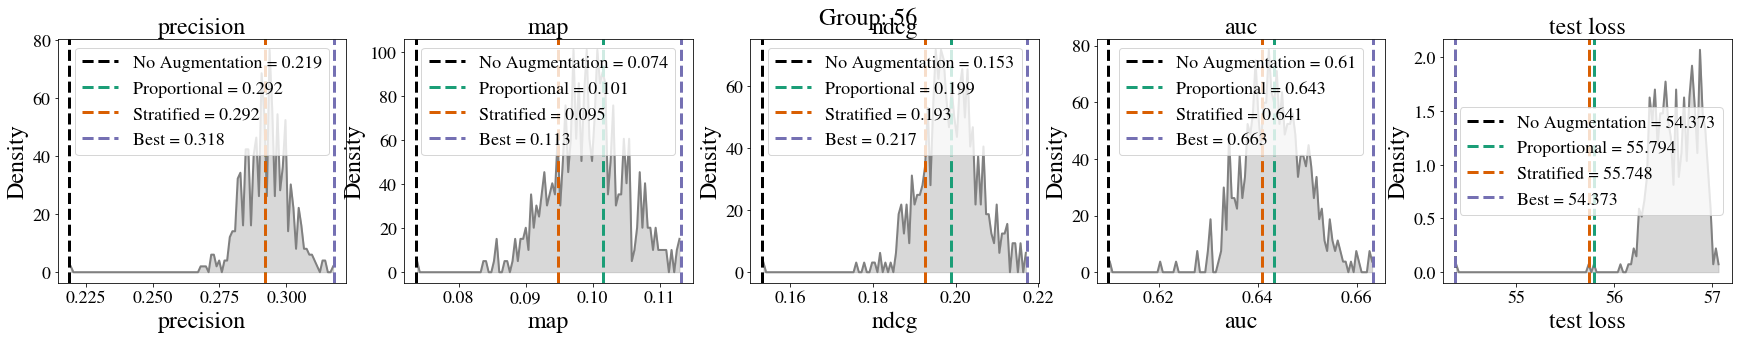

In [84]:
colors = ["black", "#1b9e77", "#d95f02", "#7570b3"]
def plot_density_with_baseline(values, baseline_tuples, value_name="Values", title="Density Plot", ax=None):
    """
    Pure Matplotlib density plot with a vertical dashed baseline line.
    """
    values = np.asarray(values)

    # Compute histogram-based density estimate
    density, bins = np.histogram(values, bins=100, density=True)
    centers = 0.5 * (bins[:-1] + bins[1:])

    if ax == None:
        fig, ax = plt.subplots()

    ax.plot(centers, density, linewidth=2, color="gray")
    ax.fill_between(centers, density, alpha=0.3, color="gray")

    for baseline_idx, (baseline_name, baseline_val) in enumerate(baseline_tuples):
        ax.axvline(baseline_val, 
                   color=colors[baseline_idx],
                   linestyle="--", linewidth=3, 
                   label=f"{baseline_name} = {round(baseline_val, 3)}")

    ax.set_title(title)
    ax.set_xlabel(value_name)
    ax.set_ylabel("Density")
    ax.legend()

for label in mixing_results_by_group:
    metric_names = list(mixing_results_by_group[label]["validation metrics"][0].keys())
    metric_dicts = mixing_results_by_group[label]["validation metrics"]
    
    fig, axs = plt.subplots(ncols=len(metric_names), figsize=(6*len(metric_names), 4.5))
    fig.suptitle(f"Group: {label}")
    for metric_idx, metric_name in enumerate(metric_names):
        metric_vals = [metric_dict[metric_name] for metric_dict in metric_dicts]
        plot_density_with_baseline(metric_vals,
                                  baseline_tuples=[
                                      ("No Augmentation", metric_vals[0]), 
                                      ("Proportional", metric_vals[1]),
                                      ("Stratified", metric_vals[2]),
                                      ("Best", np.min(metric_vals) if "loss" in metric_name else np.max(metric_vals))
                                  ],
                                  value_name=metric_name,
                                  title=metric_name,
                                  ax=axs[metric_idx])


In [85]:
## Identify the best full-augmentation mix and append its test metric
metric_name = "precision"

group_labels = list(mixing_results_by_group.keys())
optimal_ps = []

for label in group_labels:
    optimal_validation_idx = np.argmax([
        metric_dict[metric_name]
        for metric_dict in mixing_results_by_group[label]["validation metrics"]
    ])
    
    optimal_p = mixing_results_by_group[label]["validation ps"][optimal_validation_idx]
    optimal_ps.append([optimal_p[group_label] for group_label in all_labels])

    num_validation = len(mixing_results_by_group[label]["validation metrics"])
    num_test = len(mixing_results_by_group[label]["test metrics"])
    gap = num_test - num_validation
    assert gap in [1, 4]
    if gap == 4:
        # TEMPORARY: accommodate duplicate entries in test metrics.
        # first three are duplicates of no aug, stratified, and proportional. the last one is best_val
        optimal_test_idx = optimal_validation_idx + 3
    elif gap == 1:
        optimal_test_idx = optimal_validation_idx

# #     print(mixing_results_by_group[label]["test ps"][:6])
#     print(mixing_results_by_group[label]["test ps"][optimal_validation_idx])
#     print(mixing_results_by_group[label]["test ps"][-1])
    
    assert mixing_results_by_group[label]["test ps"][optimal_validation_idx] == \
        mixing_results_by_group[label]["test ps"][-1]
    
    mixing_results_by_group[label]["test metrics"].append(
        mixing_results_by_group[label]["test metrics"][optimal_test_idx]
    )


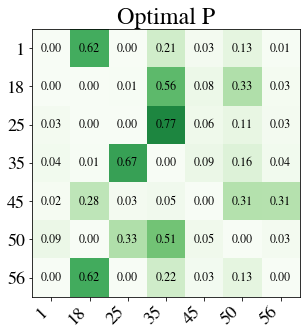

In [86]:
fig, ax = plt.subplots(figsize=(5,5))

# Background
n_rows = len(group_labels)
n_cols = len(all_labels)

optimal_ps = np.array(optimal_ps)

ax.imshow(np.zeros_like(optimal_ps, dtype=float), cmap='gray', vmin=0, vmax=1)

# Fill each cell manually
for i in range(n_rows):
    for j in range(n_cols):

        coef = optimal_ps[i, j]
        color = plt.cm.get_cmap("Greens")(coef)
        
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, facecolor=color))

        # Annotate numeric value
        ax.text(j, i, f"{optimal_ps[i, j]:.2f}", ha="center", va="center", fontsize=12)

# Tick settings
ax.set_xticks(np.arange(n_cols))
ax.set_yticks(np.arange(n_rows))
ax.set_xticklabels(all_labels, rotation=45, ha='right')
ax.set_yticklabels(group_labels)

# Axes limits
ax.set_xlim(-0.5, n_cols - 0.5)
ax.set_ylim(n_rows - 0.5, -0.5)

ax.set_aspect("equal")
ax.set_title("Optimal P")
plt.tight_layout()
plt.show()

,Stratified,Optimal Full Mixing
1,2.369077,4.488778
18,-1.212460,-0.969968
25,-0.336394,0.154560
35,-0.018060,1.625429
45,-0.651607,-0.912250
50,-0.961076,-0.240269
56,0.758853,-0.084317


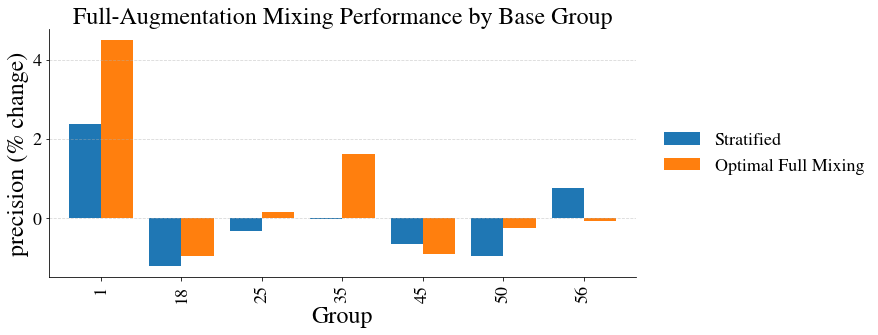

In [87]:
import pandas as pd

def percent_change(old, new):
    return 100 * (new - old) / old

mixing_alg_to_idx = {
    "No Augmentation": 0,
    "Proportional": 1,
    "Stratified": 2,
    "Optimal Full Mixing": -1,
}

dataframe_dict = {}
labels = list(mixing_results_by_group.keys())
for mixing_alg_name, mixing_alg_idx in mixing_alg_to_idx.items():
    if mixing_alg_idx in [0,1]:
        continue
    mixing_alg_values_by_label = [
#             mixing_results_by_group[label]["test metrics"][mixing_alg_idx][metric_name]
        percent_change(
            mixing_results_by_group[label]["test metrics"][1][metric_name],
            mixing_results_by_group[label]["test metrics"][mixing_alg_idx][metric_name]
        )
        for label in labels
    ]
    
    dataframe_dict[mixing_alg_name] = mixing_alg_values_by_label

metric_values_df = pd.DataFrame(dataframe_dict, index=labels)


fig, ax = plt.subplots()

metric_values_df.plot(
    ax=ax,
    kind="bar",
    figsize=(15, 5),
    width=0.8,
)

ax.set_xlabel("Group")
ax.set_ylabel(metric_name + " (% change)")
ax.set_title("Full-Augmentation Mixing Performance by Base Group")

ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Move legend outside right
ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# Make room on the right
plt.tight_layout(rect=[0, 0, 0.85, 1])


metric_values_df
